# Exploratory Data Analysis (EDA)
## Fitness Class Booking Analysis

In [8]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [9]:
# =========================================================
# LOAD CLEANED DATASET
# =========================================================

df = pd.read_csv('/content/cleaned_preprocessed_dataset_Tejaswini Yeluduti.csv')

print("Dataset Loaded Successfully")

display(df.head())

Dataset Loaded Successfully


,activity_site_id,activity_description,booking_end_datetime,booking_start_time,max_bookees,number_booked,price_inr,year,month,day,day_name
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,14:45:00,-0.475775,12,-1.709436,2018,4,8,Sunday
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,14:45:00,-0.475775,15,-1.709436,2018,4,15,Sunday
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,14:45:00,-0.475775,14,-1.709436,2018,4,22,Sunday
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,14:45:00,-0.475775,9,-1.709436,2018,4,29,Sunday
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,14:45:00,-0.475775,7,-1.709436,2018,5,6,Sunday


In [10]:
df['booking_end_datetime'] = pd.to_datetime(
    df['booking_end_datetime']
)

In [11]:
# =========================================================
# DATA OVERVIEW
# =========================================================

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (3289, 11)

Columns:
Index(['activity_site_id', 'activity_description', 'booking_end_datetime',
       'booking_start_time', 'max_bookees', 'number_booked', 'price_inr',
       'year', 'month', 'day', 'day_name'],
      dtype='object')

Data Types:
activity_site_id                object
activity_description            object
booking_end_datetime    datetime64[ns]
booking_start_time              object
max_bookees                    float64
number_booked                    int64
price_inr                      float64
year                             int64
month                            int64
day                              int64
day_name                        object
dtype: object

Missing Values:
activity_site_id        0
activity_description    0
booking_end_datetime    0
booking_start_time      0
max_bookees             0
number_booked           0
price_inr               0
year                    0
month                   0
day                     0
day_name        

In [12]:
# =========================================================
# DESCRIPTIVE STATISTICS
# =========================================================

display(df.describe())

,booking_end_datetime,max_bookees,number_booked,price_inr,year,month,day
count,3289,3.289000e+03,3289.000000,3.289000e+03,3289.0,3289.000000,3289.000000
mean,2018-05-16 08:58:57.610215680,1.209802e-16,17.088781,-6.913155e-17,2018.0,5.010946,15.707814
min,2018-04-01 00:00:00,-1.999978e+00,1.000000,-1.709436e+00,2018.0,4.000000,1.000000
25%,2018-04-24 00:00:00,-5.420451e-01,10.000000,-6.977698e-01,2018.0,4.000000,8.000000
50%,2018-05-16 00:00:00,-1.444272e-01,16.000000,-4.448533e-01,2018.0,5.000000,16.000000
75%,2018-06-08 00:00:00,1.869211e-01,24.000000,8.197296e-01,2018.0,6.000000,23.000000
max,2018-06-30 00:00:00,2.506359e+00,64.000000,2.716604e+00,2018.0,6.000000,31.000000
std,NaN,1.000152e+00,9.504098,1.000152e+00,0.0,0.815678,8.603637


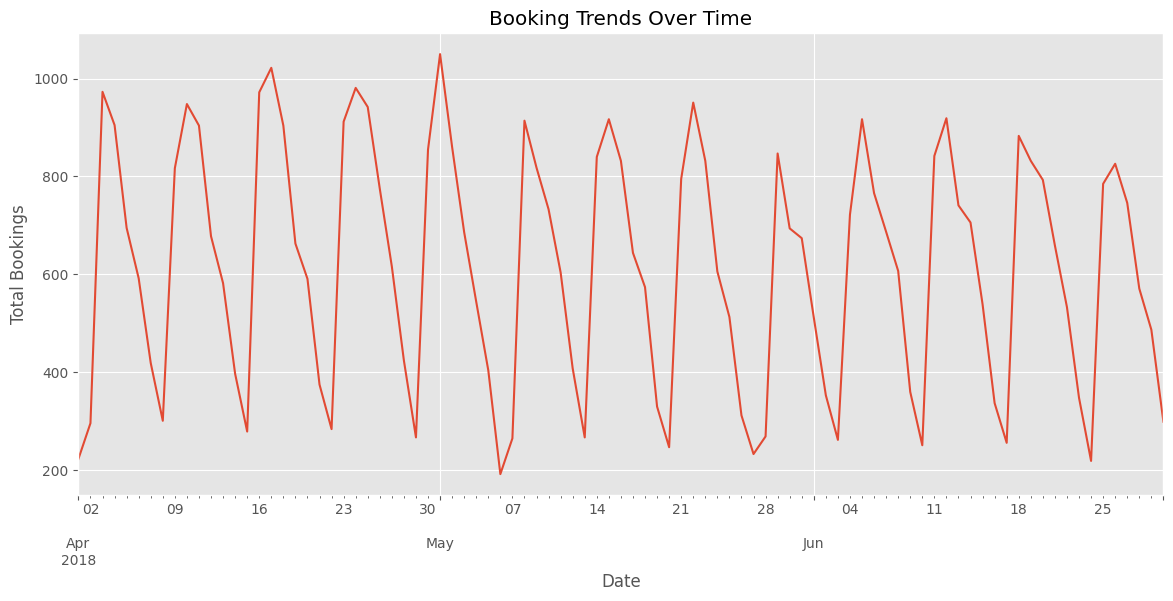

In [13]:
# =========================================================
# BOOKING TREND ANALYSIS
# =========================================================

booking_trend = df.groupby('booking_end_datetime')['number_booked'].sum()

plt.figure(figsize=(14,6))

booking_trend.plot()

plt.title('Booking Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Total Bookings')

plt.show()

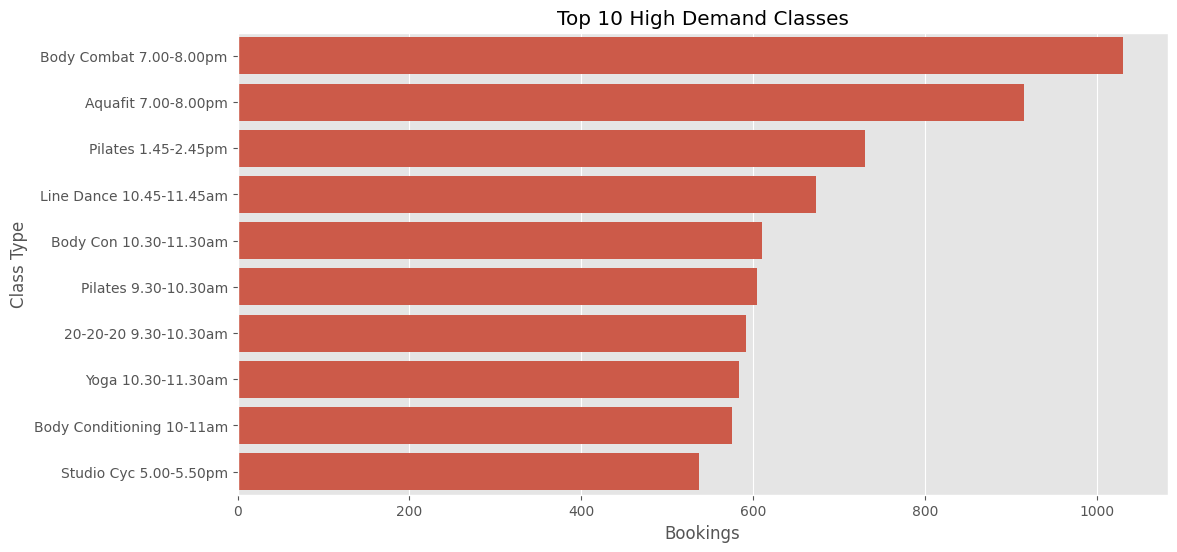

In [14]:
# =========================================================
# HIGH DEMAND CLASSES
# =========================================================

top_classes = (
    df.groupby('activity_description')['number_booked']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_classes.values,
    y=top_classes.index
)

plt.title('Top 10 High Demand Classes')
plt.xlabel('Bookings')
plt.ylabel('Class Type')

plt.show()

In [15]:
# =========================================================
# CREATE DATE FEATURES
# =========================================================

df['booking_end_datetime'] = pd.to_datetime(
    df['booking_end_datetime']
)

df['year'] = df['booking_end_datetime'].dt.year
df['month'] = df['booking_end_datetime'].dt.month
df['day'] = df['booking_end_datetime'].dt.day
df['day_name'] = df['booking_end_datetime'].dt.day_name()

print("Date Features Created Successfully")

Date Features Created Successfully


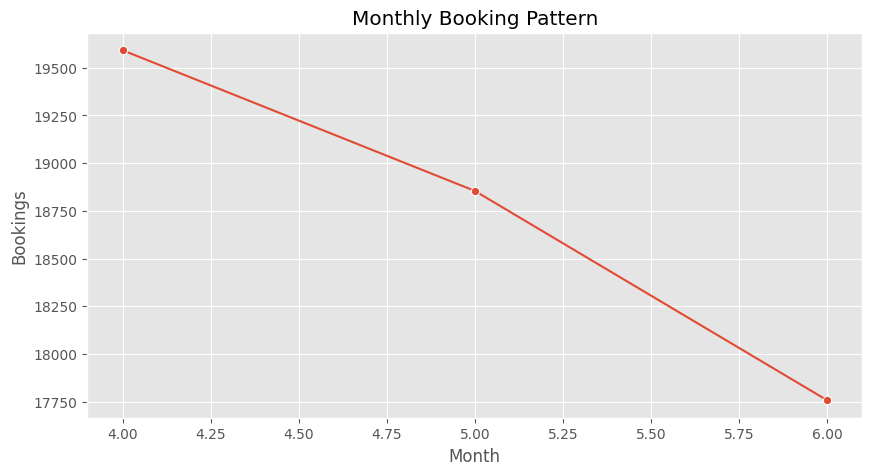

In [16]:
# =========================================================
# SEASONAL ANALYSIS
# =========================================================

monthly_bookings = (
    df.groupby('month')['number_booked']
    .sum()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_bookings.index,
    y=monthly_bookings.values,
    marker='o'
)

plt.title('Monthly Booking Pattern')
plt.xlabel('Month')
plt.ylabel('Bookings')

plt.show()

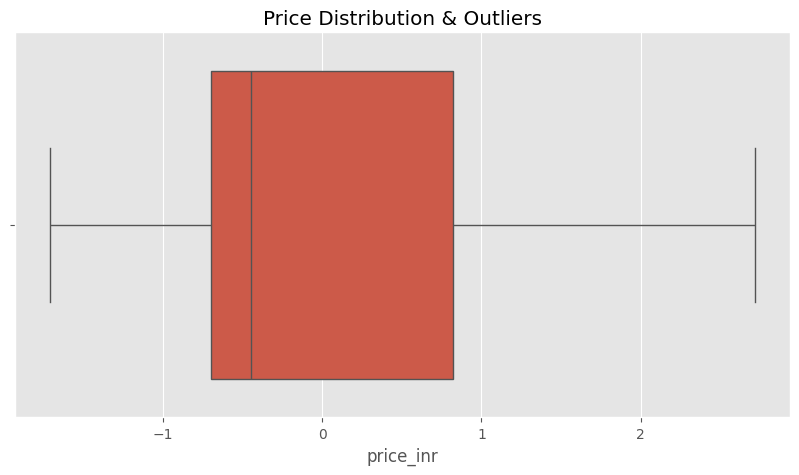

In [17]:
# =========================================================
# OUTLIER DETECTION
# =========================================================

plt.figure(figsize=(10,5))

sns.boxplot(x=df['price_inr'])

plt.title('Price Distribution & Outliers')

plt.show()

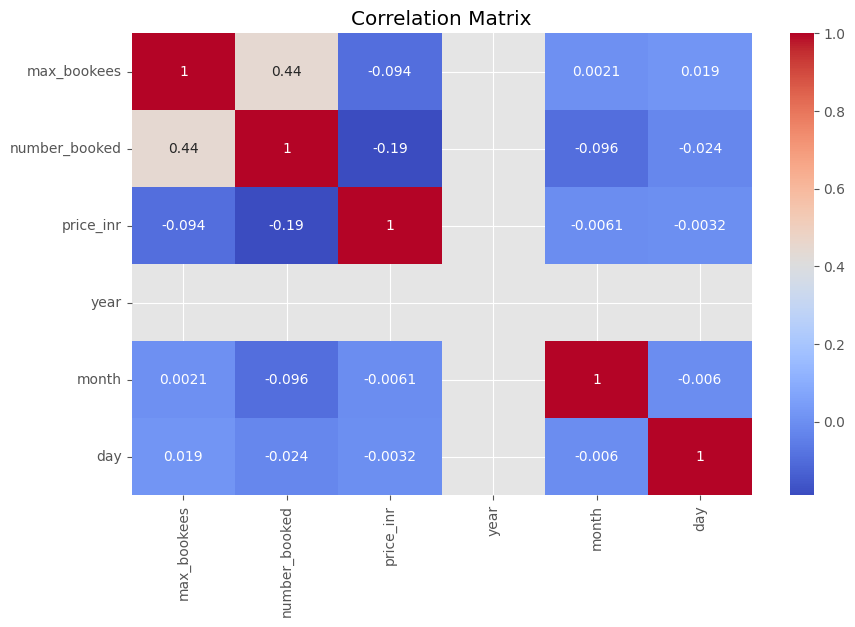

In [18]:
# =========================================================
# CORRELATION ANALYSIS
# =========================================================

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

# Key Insights

- Certain fitness classes show consistently high booking demand.
- Peak booking periods occur during specific time ranges.
- Pricing impacts attendance behavior.
- Some price outliers are visible in the dataset.
- Strong correlations exist between booking patterns and class popularity.

# Conclusion

The EDA process revealed important booking trends, seasonal patterns, and customer demand behavior.

These insights will support:
- Price elasticity modeling
- Demand forecasting
- Dynamic pricing strategy development
- Revenue optimization